In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

In [18]:
path='/projekt1/ag_maahn/data_obs_nobackup/amazonas/forest_loss/'

kacheln1 = [
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_080W.tif")
]
mrd1 = merge_arrays(kacheln1)

In [19]:
path2='/projekt1/ag_maahn/data_obs_nobackup/amazonas/cover2000/'

kacheln2 = [
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_080W.tif")
]

mrd2 =merge_arrays(kacheln2)

In [20]:
loss = mrd1.to_dataset(name="lossyear")
cvr = mrd2.to_dataset(name="cover2000")
ds=xr.merge([loss, cvr])
ds

/tmp/ipykernel_318577/1432654727.py:3: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([loss, cvr])


<xarray.Dataset> Size: 38GB
Dimensions:      (x: 160000, y: 120000, band: 1)
Coordinates:
  * x            (x) float64 1MB -80.0 -80.0 -80.0 -80.0 ... -40.0 -40.0 -40.0
  * y            (y) float64 960kB 10.0 10.0 9.999 9.999 ... -20.0 -20.0 -20.0
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    lossyear     (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    cover2000    (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [21]:
th=50 # % Threshold for beeing marked as forest, following the definition in the dataset for forest loss

maxX = round(float(ds['x'].max()),0)
minX = round(float(ds['x'].min()),0)

maxY = round(float(ds['y'].max()),0)
minY = round(float(ds['y'].min()),0)
 
#x_range = np.arange(minX, maxX+1)
#y_range = np.arange(minY, maxY+1)
#print(x_range)
#print(y_range)

In [22]:
# 1. create bolean arrays
cond_forest  = ds['cover2000'] >= th
cond_no_loss = ds['lossyear'] <= 1

# 2. Group in 1x1° bins and sum
forest_count      = cond_forest.groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

still_forest_count = (cond_forest & cond_no_loss) \
                               .groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

# 3. Degree of Deforestation
DoD = (forest_count - still_forest_count) / forest_count.where(forest_count > 0)

#Difference (pixel count) of forest area in 2001 and 2024

Fo_diff=forest_count - still_forest_count

In [23]:
ds_dod = DoD.to_dataset(name="DoD")
ds_Fo_diff= Fo_diff.to_dataset(name="Difference")

In [24]:
# set boundary values for map-plots
lon_min, lon_max = -85, -35
lat_min, lat_max = -35, 15

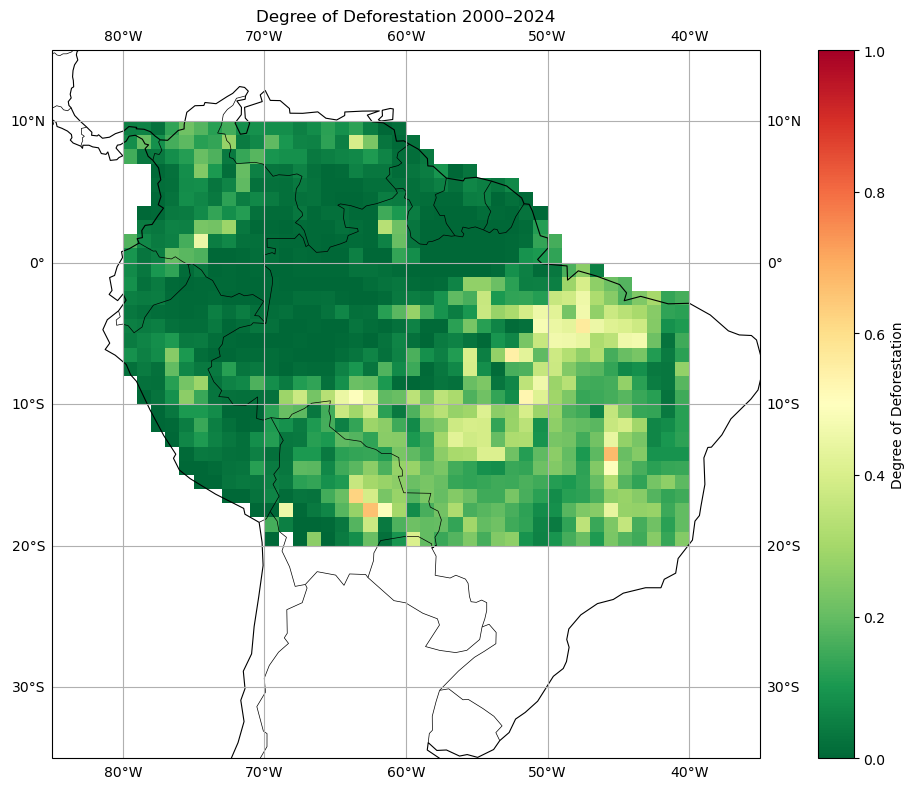

In [25]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

DoD.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    cbar_kwargs={'label': 'Degree of Deforestation'}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))

ax.set_title('Degree of Deforestation 2000–2024')
plt.tight_layout()
plt.show()

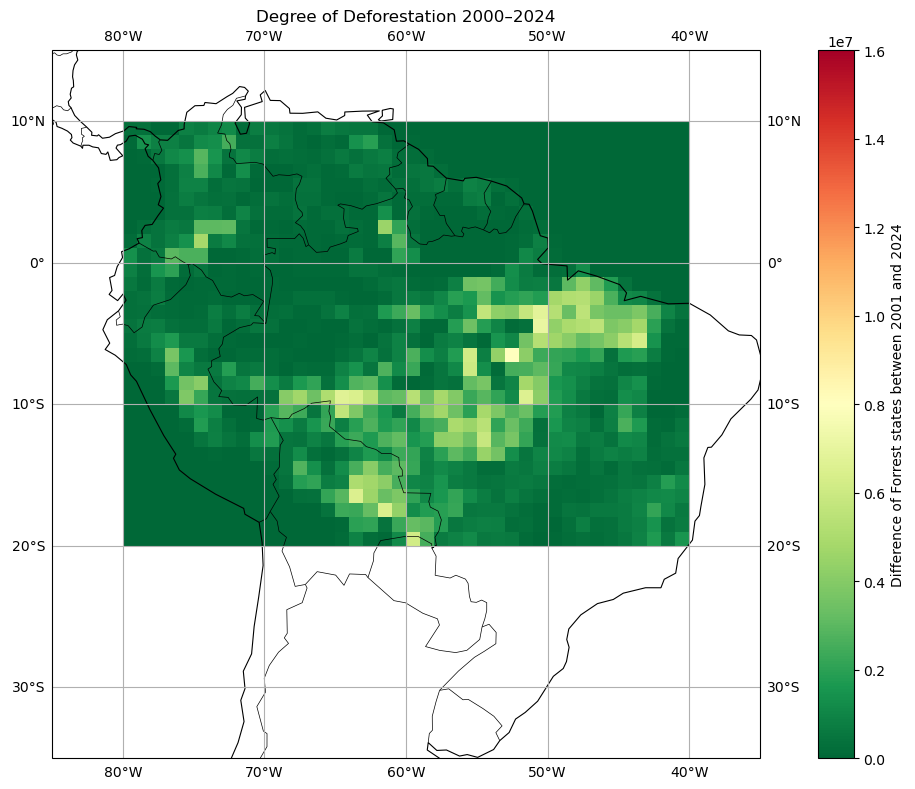

In [26]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

Fo_diff.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlGn_r',
    vmin=0, vmax=16000000,
    cbar_kwargs={'label': 'Difference of Forrest states between 2001 and 2024'}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))

ax.set_title('Degree of Deforestation 2000–2024')
plt.tight_layout()
plt.show()

In [27]:
dataset='CMF_low.nc'
modis=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/'+dataset)

In [28]:
time_num = (modis.time - modis.time[0]).dt.days.values

def linear_trend_with_pvalue(y):
    mask = ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    slope, _, _, pvalue, _ = stats.linregress(time_num[mask], y[mask])
    return slope, pvalue

# Slope und p-Wert berechnen
slope, pvalue = xr.apply_ufunc(
    linear_trend_with_pvalue,
    modis["Mean"],
    input_core_dims=[["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    output_dtypes=[float, float]
)

trend_modis = xr.Dataset({
    "trend_Mean": slope.transpose("latitude", "longitude"),
    "pvalue":     pvalue.transpose("latitude", "longitude")
})

In [29]:
trend_modis['trend_Mean']=trend_modis['trend_Mean']*365*10
trend_modis

<xarray.Dataset> Size: 20kB
Dimensions:     (latitude: 30, longitude: 40)
Coordinates:
  * latitude    (latitude) float64 240B -19.5 -18.5 -17.5 -16.5 ... 7.5 8.5 9.5
  * longitude   (longitude) float64 320B -79.5 -78.5 -77.5 ... -42.5 -41.5 -40.5
Data variables:
    trend_Mean  (latitude, longitude) float64 10kB -0.002897 ... 0.02626
    pvalue      (latitude, longitude) float64 10kB 0.5253 0.539 ... 4.047e-08

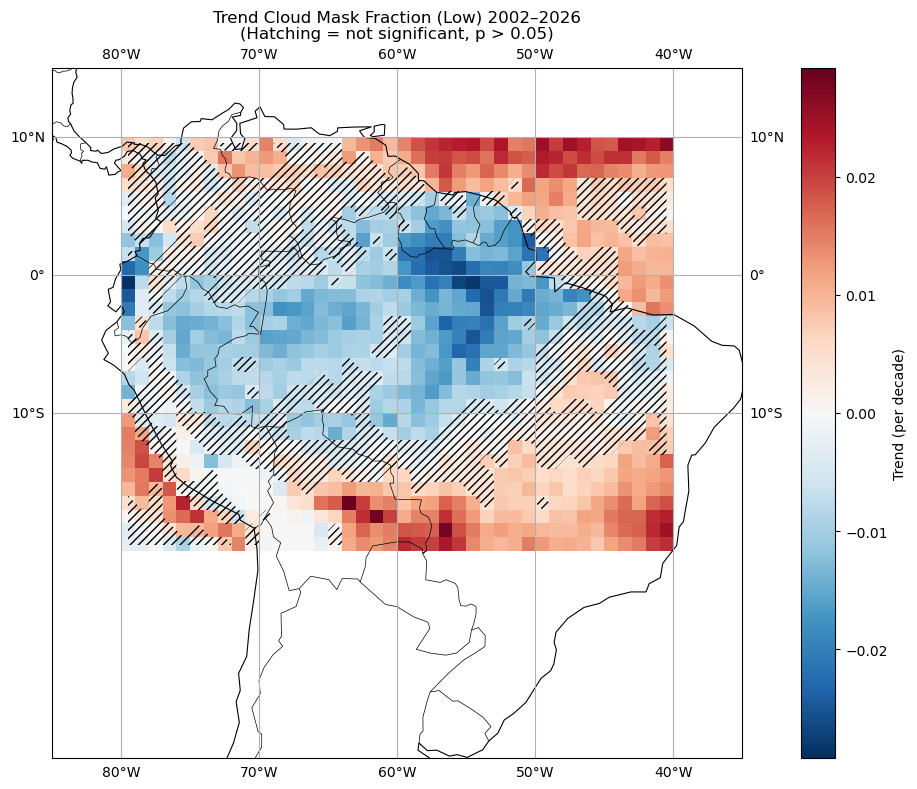

In [30]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

(trend_modis["trend_Mean"]).plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs={"label": "Trend (per decade)"}
)

# Non-significant areas hatched (p > 0.05)
sig_mask = trend_modis["pvalue"] > 0.05
ax.contourf(
    trend_modis.longitude, trend_modis.latitude,
    sig_mask.values,
    levels=[0.5, 1.5],
    hatches=["////"],
    colors="none",
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-10, 11, 10))

ax.set_title("Trend Cloud Mask Fraction (Low) 2002–2026\n(Hatching = not significant, p > 0.05)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_318577/2960370601.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


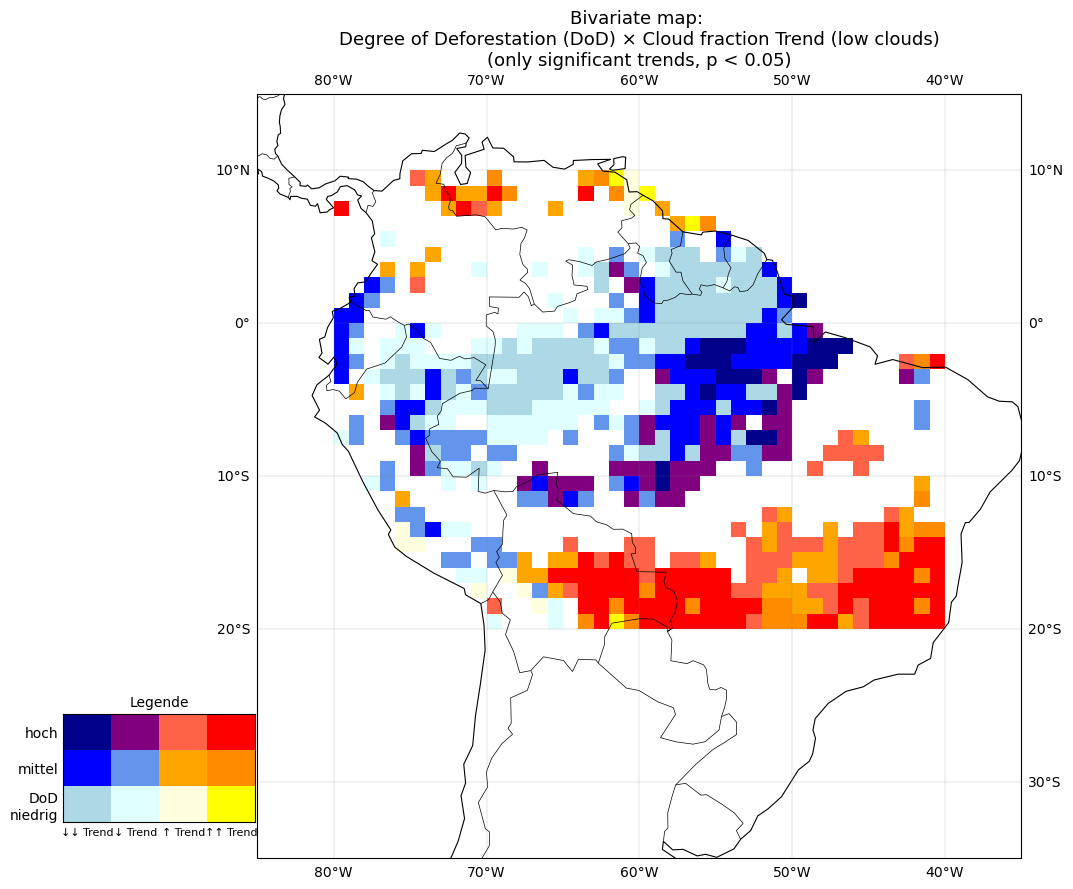

In [16]:
# ── 1. Interpolate Modis Data to Hansen-Grid ──────────────────────────────────
trend_sig = trend_modis["trend_Mean"].where(trend_modis["pvalue"] < 0.05)

x_mids = np.array([iv.mid for iv in ds_dod.x_bins.values])
y_mids = np.array([iv.mid for iv in ds_dod.y_bins.values])

trend_interp = trend_sig.interp(
    latitude=y_mids,
    longitude=x_mids,
    method="nearest"
)

# ── 2. extract values──────────────────────────────────────────────────────
dod_vals   = ds_dod["DoD"].squeeze().values            # (30, 40)
fodif_vals = ds_Fo_diff["Difference"].squeeze().values # (30, 40)
trend_vals = trend_interp.values                       # (30, 40)

# ── 3. classifikation ─────────────────────────────────────────────────────────
both_valid = ~np.isnan(dod_vals) & ~np.isnan(trend_vals)
dod_t = np.nanpercentile(dod_vals[both_valid], [33, 66])
fodif_t = np.nanpercentile(dod_vals[both_valid], [33, 66])

# Trend: 4 classes with 0 as natürlicher threshold
neg_vals = trend_vals[both_valid & (trend_vals < 0)]
pos_vals = trend_vals[both_valid & (trend_vals > 0)]
trend_t = [np.median(neg_vals), 0, np.median(pos_vals)]
# → 0: stark neg | 1: schwach neg | 2: schwach pos | 3: stark pos

def classify_dod(arr, thresholds):
    out = np.full(arr.shape, np.nan)
    out[arr <= thresholds[0]] = 0
    out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
    out[arr > thresholds[1]] = 2
    return out

def classify_trend(arr, thresholds):
    out = np.full(arr.shape, np.nan)
    out[arr <= thresholds[0]] = 0
    out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
    out[(arr > thresholds[1]) & (arr <= thresholds[2])] = 2
    out[arr > thresholds[2]] = 3
    return out

dod_class   = classify_dod(dod_vals,   dod_t)
trend_class = classify_trend(trend_vals, trend_t)

# combined Index 0–11 (3 DoD × 4 Trend)
combo = np.full(dod_vals.shape, np.nan)
combo[both_valid] = dod_class[both_valid] * 4 + trend_class[both_valid]

# ── 4. Bivariate colour matrix (3×4) ───────────────────────────────────────────
# Zeilen = DoD (0=niedrig → 2=hoch), Spalten = Trend (0=stark neg → 3=stark pos)
bivar_colors = [
    "lightblue",   # DoD low,  Trend stark neg
    "lightcyan",   # DoD low,  Trend schwach neg
    "lightyellow", # DoD low,  Trend schwach pos
    "yellow",      # DoD low,  Trend stark pos
    "blue",        # DoD mid,  Trend stark neg
    "cornflowerblue", # DoD mid, Trend schwach neg
    "orange",      # DoD mid,  Trend schwach pos
    "darkorange",  # DoD mid,  Trend stark pos
    "darkblue",    # DoD high, Trend stark neg
    "purple",      # DoD high, Trend schwach neg
    "tomato",      # DoD high, Trend schwach pos
    "red",         # DoD high, Trend stark pos
]
cmap_bivar = ListedColormap(bivar_colors)

# ── 5. plot map ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)

im = ax.pcolormesh(
    x_mids, y_mids, combo,
    cmap=cmap_bivar, vmin=0, vmax=11,
    transform=ccrs.PlateCarree(), zorder=1
)

# Mask for NaN (not significant or no forrest)
nan_mask = np.where(np.isnan(combo), 0.4, np.nan)
ax.pcolormesh(
    x_mids, y_mids, nan_mask,
    cmap=ListedColormap(["white"]), vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
ax.set_title("Bivariate map: \n"
             "Degree of Deforestation (DoD) × Cloud fraction Trend (low clouds)\n"
             "(only significant trends, p < 0.05)", fontsize=13)

# ── 6. Bivariate legend  ──────────────────────────────────────
legend_ax = fig.add_axes([0.02, 0.08, 0.16, 0.12])
legend_grid = np.arange(12).reshape(3, 4)
legend_ax.imshow(legend_grid, cmap=cmap_bivar, vmin=0, vmax=11,
                 origin="lower", aspect="auto")
legend_ax.set_xticks([0, 1, 2, 3])
legend_ax.set_xticklabels(["↓↓ Trend", "↓ Trend", "↑ Trend", "↑↑ Trend"], fontsize=8)
legend_ax.set_yticks([0, 1, 2])
legend_ax.set_yticklabels(["DoD\nniedrig", "mittel", "hoch"], fontsize=10)
legend_ax.set_title("Legende", fontsize=10)
legend_ax.tick_params(length=0)

plt.tight_layout()
plt.savefig("bivariate_dod_wolkentrend.png", dpi=150, bbox_inches="tight")
plt.show()

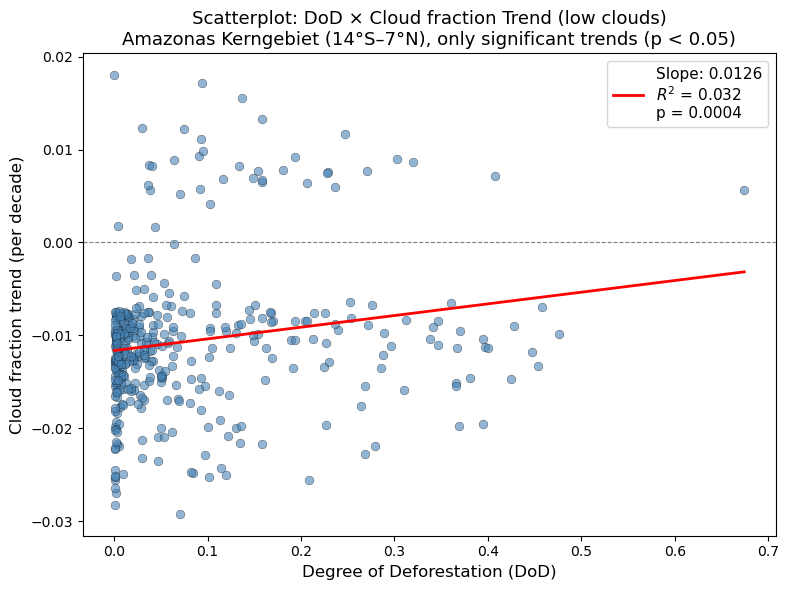

In [17]:
from scipy import stats

# ── Auf Amazonas-Kernbereich einschränken (14°S bis 7°N) ─────────────────────
lat_mask       = (y_mids >= -14) & (y_mids <= 7)
dod_vals_amz   = dod_vals[lat_mask, :]
trend_vals_amz = trend_vals[lat_mask, :]

both_valid_amz = ~np.isnan(dod_vals_amz) & ~np.isnan(trend_vals_amz)

# ── Daten vorbereiten ─────────────────────────────────────────────────────────
dod_flat   = dod_vals_amz[both_valid_amz].flatten()
trend_flat = trend_vals_amz[both_valid_amz].flatten()

# ── Lineare Regression ────────────────────────────────────────────────────────
slope, intercept, r_value, p_value, std_err = stats.linregress(dod_flat, trend_flat)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(dod_flat, trend_flat, alpha=0.6, edgecolors="k", linewidths=0.3, s=40, color="steelblue")

x_line = np.linspace(dod_flat.min(), dod_flat.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2, label=f"Slope: {slope:.4f}\n$R^2$ = {r_value**2:.3f}\np = {p_value:.4f}")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

ax.set_xlabel("Degree of Deforestation (DoD)", fontsize=12)
ax.set_ylabel("Cloud fraction trend (per decade)", fontsize=12)
ax.set_title("Scatterplot: DoD × Cloud fraction Trend (low clouds)\n"
             "Amazonas Kerngebiet (14°S–7°N), only significant trends (p < 0.05)", fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("scatterplot_dod_wolkentrend_amazonas.png", dpi=150, bbox_inches="tight")
plt.show()